# Thesis EDA: Feature Audit and Selection Evidence

This notebook audits every currently generated, anonymized feature family before model fitting. It produces descriptive evidence for feature inclusion, transformation, and exclusion decisions; it does not fit outcome-prediction or HMM models.

**Selection principles**

- HMM candidates must be window-level, sufficiently observed, variable, and not redundant with another retained candidate.
- Prediction candidates must be task-level or aggregable to group-task level, sufficiently observed, and parsimonious for the small independent-group sample.
- QC flags, identifiers, raw paths, and derived labels are excluded from candidate feature sets.
- Generated shortlists are review aids. Final inclusion remains theory-led and must record modality provenance and known caveats.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

PROJECT_ROOT = Path.cwd().resolve().parent
if not (PROJECT_ROOT / "analysis").is_dir():
    raise RuntimeError("Run this notebook with its working directory set to analysis/.")

RESULTS_DIR = PROJECT_ROOT / "analysis" / "results"
OUTPUT_DIR = RESULTS_DIR / "feature_eda"
OUTPUT_DIR.mkdir(exist_ok=True)

SOURCES = {
    "physiology": (RESULTS_DIR / "physio_features" / "physio_window_30s.tsv", "window"),
    "eye_tracking": (RESULTS_DIR / "et_features_v20260812" / "et_window_30s.tsv", "window"),
    "audio_prosody": (RESULTS_DIR / "participant_audio_features.tsv", "participant_task"),
    "turn_taking": (RESULTS_DIR / "transcript_features_full" / "transcript_group_task.tsv", "group_task"),
    "lexical": (RESULTS_DIR / "lexical_window_30s.tsv", "window"),
    "bert_semantics": (RESULTS_DIR / "bert_embeddings_window_30s.tsv", "window"),
    "dialogue_acts_keyword": (RESULTS_DIR / "da_keyword_window_30s.tsv", "window"),
    "dialogue_acts_nli": (RESULTS_DIR / "da_window_30s.tsv", "window"),
    "semantic_continuity": (RESULTS_DIR / "semantic_continuity_window_30s.tsv", "window"),
    "group_dynamics": (RESULTS_DIR / "cross_modal" / "features_group_dynamics_window_30s.tsv", "window"),
    "semantic_biomarkers": (RESULTS_DIR / "cross_modal" / "semantic_biomarkers_window_30s.tsv", "window"),
    "self_report_targets": (RESULTS_DIR / "collective_features_v20260905" / "collective_task_selfreport.tsv", "group_task"),
    "participant_traits": (RESULTS_DIR / "participant_traits.tsv", "participant"),
}

IDENTIFIER_TOKENS = ("id", "group", "session", "task", "participant", "window", "source", "path")
EXCLUDED_TOKENS = ("qc", "flag", "available", "coverage", "duration", "sample_rate", "n_windows", "n_participants", "index", "label")


def load_sources() -> tuple[dict[str, pd.DataFrame], pd.DataFrame]:
    """Load available generated tables and record unavailable sources explicitly."""
    loaded: dict[str, pd.DataFrame] = {}
    inventory: list[dict[str, object]] = []
    for family, (path, granularity) in SOURCES.items():
        available = path.exists()
        frame = pd.read_csv(path, sep="\t") if available else None
        if frame is not None:
            loaded[family] = frame
        inventory.append({
            "family": family,
            "granularity": granularity,
            "path": str(path.relative_to(PROJECT_ROOT)),
            "available": available,
            "rows": len(frame) if frame is not None else 0,
            "columns": len(frame.columns) if frame is not None else 0,
        })
    return loaded, pd.DataFrame(inventory)


def is_candidate_column(column: str, values: pd.Series) -> bool:
    """Return whether a numeric column is a feature rather than metadata or a QC field."""
    normalized = column.lower()
    if not pd.api.types.is_numeric_dtype(values) or pd.api.types.is_bool_dtype(values):
        return False
    if any(token in normalized for token in IDENTIFIER_TOKENS + EXCLUDED_TOKENS):
        return False
    return True


frames, source_inventory = load_sources()
source_inventory.to_csv(OUTPUT_DIR / "source_inventory.tsv", sep="\t", index=False)
source_inventory

,family,granularity,path,available,rows,columns
0,physiology,window,analysis\results\physio_features\physio_window...,True,8588,156
1,eye_tracking,window,analysis\results\et_features_v20260812\et_wind...,True,8248,38
2,audio_prosody,participant_task,analysis\results\participant_audio_features.tsv,True,108,8
3,turn_taking,group_task,analysis\results\transcript_features_full\tran...,True,37,21
4,lexical,window,analysis\results\lexical_window_30s.tsv,True,682,43
5,bert_semantics,window,analysis\results\bert_embeddings_window_30s.tsv,True,813,15
6,dialogue_acts_keyword,window,analysis\results\da_keyword_window_30s.tsv,True,597,16
7,dialogue_acts_nli,window,analysis\results\da_window_30s.tsv,True,597,17
8,semantic_continuity,window,analysis\results\semantic_continuity_window_30...,True,514,5
9,group_dynamics,window,analysis\results\cross_modal\features_group_dy...,True,2430,12


## Feature Coverage, Distributions, and Selection Diagnostics

For every numeric, non-metadata column, calculate coverage, central tendency, dispersion, sparsity, skew, and observed range. These diagnostics make transformation and exclusion choices traceable.

In [2]:
def feature_summary(family: str, granularity: str, frame: pd.DataFrame) -> pd.DataFrame:
    """Summarize every numeric analytic feature in one generated table."""
    records: list[dict[str, object]] = []
    for column in frame.columns:
        values = frame[column]
        if not is_candidate_column(column, values):
            continue
        observed = values.dropna()
        if observed.empty:
            continue
        records.append({
            "family": family,
            "granularity": granularity,
            "feature": column,
            "n_rows": len(values),
            "n_observed": len(observed),
            "coverage_pct": 100 * len(observed) / len(values),
            "zero_pct": 100 * (observed == 0).mean(),
            "mean": observed.mean(),
            "median": observed.median(),
            "sd": observed.std(),
            "min": observed.min(),
            "max": observed.max(),
            "iqr": observed.quantile(0.75) - observed.quantile(0.25),
            "skew": skew(observed, bias=False) if len(observed) >= 3 and observed.nunique() > 1 else np.nan,
            "n_unique": observed.nunique(),
        })
    return pd.DataFrame(records)

summary_frames = [
    feature_summary(family, SOURCES[family][1], frame)
    for family, frame in frames.items()
]
feature_inventory = pd.concat(summary_frames, ignore_index=True).sort_values(["family", "feature"])
feature_inventory["low_coverage"] = feature_inventory["coverage_pct"] < 80
feature_inventory["near_constant"] = (feature_inventory["n_unique"] <= 2) | (feature_inventory["sd"] == 0)
feature_inventory["sparse_count"] = feature_inventory["zero_pct"] >= 80
feature_inventory["strongly_skewed"] = feature_inventory["skew"].abs() >= 1
feature_inventory["recommended_handling"] = np.select(
    [feature_inventory["near_constant"], feature_inventory["low_coverage"], feature_inventory["sparse_count"], feature_inventory["strongly_skewed"]],
    ["exclude: near constant", "review: low coverage", "review: sparse count", "transform or robust-scale"],
    default="eligible for theory review",
)
feature_inventory.to_csv(OUTPUT_DIR / "feature_inventory.tsv", sep="\t", index=False)

family_overview = feature_inventory.groupby(["family", "granularity"], as_index=False).agg(
    n_features=("feature", "size"), median_coverage_pct=("coverage_pct", "median"),
    n_low_coverage=("low_coverage", "sum"), n_near_constant=("near_constant", "sum"),
    n_sparse=("sparse_count", "sum"), n_strongly_skewed=("strongly_skewed", "sum"),
)
family_overview.to_csv(OUTPUT_DIR / "feature_family_overview.tsv", sep="\t", index=False)
display(family_overview)
display(feature_inventory.head(20))

,family,granularity,n_features,median_coverage_pct,n_low_coverage,n_near_constant,n_sparse,n_strongly_skewed
0,audio_prosody,participant_task,4,100.000000,0,0,0,1
1,bert_semantics,window,11,100.000000,0,0,0,1
2,dialogue_acts_keyword,window,11,100.000000,0,0,5,10
3,dialogue_acts_nli,window,12,100.000000,0,0,0,10
4,eye_tracking,window,23,99.224054,0,0,0,17
5,lexical,window,38,75.219941,20,0,2,24
6,participant_traits,participant,6,100.000000,0,0,0,0
7,physiology,window,111,92.163484,9,0,2,82
8,self_report_targets,group_task,24,100.000000,11,0,0,1
9,semantic_biomarkers,window,121,47.012354,118,0,2,86


,family,granularity,feature,n_rows,n_observed,coverage_pct,zero_pct,mean,median,sd,min,max,iqr,skew,n_unique,low_coverage,near_constant,sparse_count,strongly_skewed,recommended_handling
134,audio_prosody,participant_task,audio_energy_mean,108,108,100.0,0.000000,0.211349,0.196813,0.080821,0.098948,0.629545,0.081584,2.000899,108,False,False,False,True,transform or robust-scale
137,audio_prosody,participant_task,audio_hnr_mean,108,108,100.0,0.000000,3.848485,3.683648,1.325427,1.528036,6.968106,2.127747,0.229864,108,False,False,False,False,eligible for theory review
135,audio_prosody,participant_task,audio_pitch_mean,108,108,100.0,0.000000,27.138907,26.641489,2.084734,23.683229,32.736706,2.895186,0.807510,108,False,False,False,False,eligible for theory review
136,audio_prosody,participant_task,audio_pitch_sd,108,108,100.0,0.000000,0.225720,0.226649,0.033829,0.139918,0.317563,0.039485,0.090360,108,False,False,False,False,eligible for theory review
195,bert_semantics,window,bert_umap1,813,813,100.0,0.000000,5.053851,-0.339483,9.742644,-1.843296,21.552654,22.178230,1.053354,813,False,False,False,True,transform or robust-scale
204,bert_semantics,window,bert_umap10,813,813,100.0,0.000000,5.627482,5.864541,0.710286,4.347182,6.689047,1.392414,-0.400336,813,False,False,False,False,eligible for theory review
196,bert_semantics,window,bert_umap2,813,813,100.0,0.000000,4.710254,4.728085,0.689121,3.654376,5.798305,1.382752,0.043533,813,False,False,False,False,eligible for theory review
197,bert_semantics,window,bert_umap3,813,813,100.0,0.000000,4.703682,4.805473,0.624690,3.349466,5.915807,0.941635,-0.098832,813,False,False,False,False,eligible for theory review
198,bert_semantics,window,bert_umap4,813,813,100.0,0.000000,4.187110,3.453153,1.656216,1.922463,7.139036,3.434379,0.881912,813,False,False,False,False,eligible for theory review
199,bert_semantics,window,bert_umap5,813,813,100.0,0.000000,6.027081,6.051092,1.357876,3.949323,8.004227,2.969158,-0.092865,813,False,False,False,False,eligible for theory review


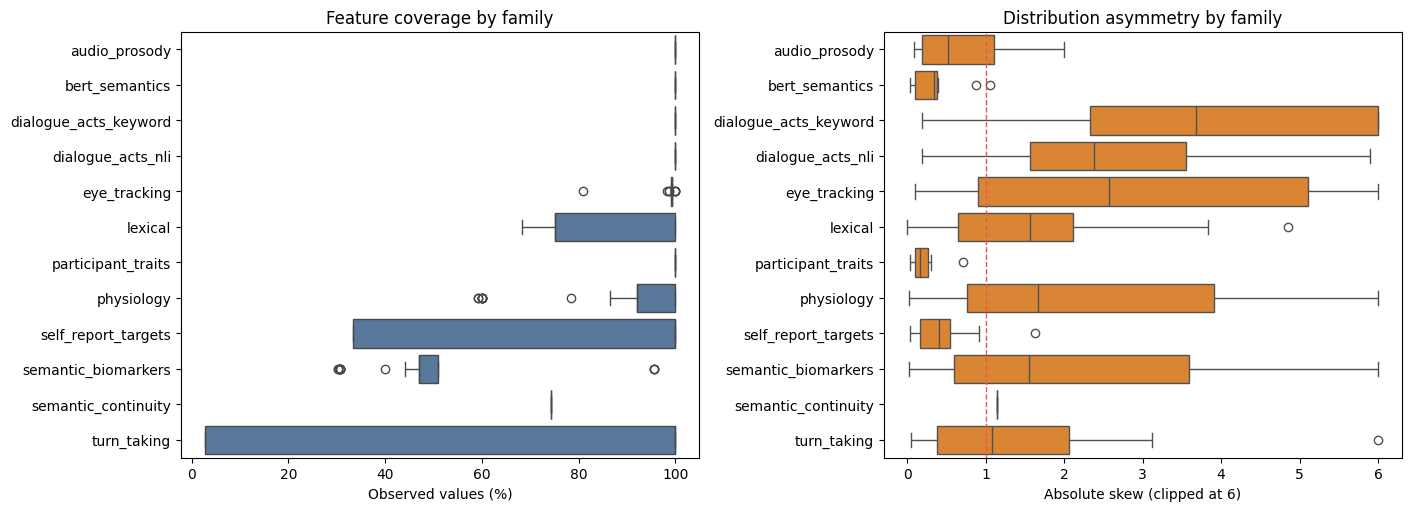

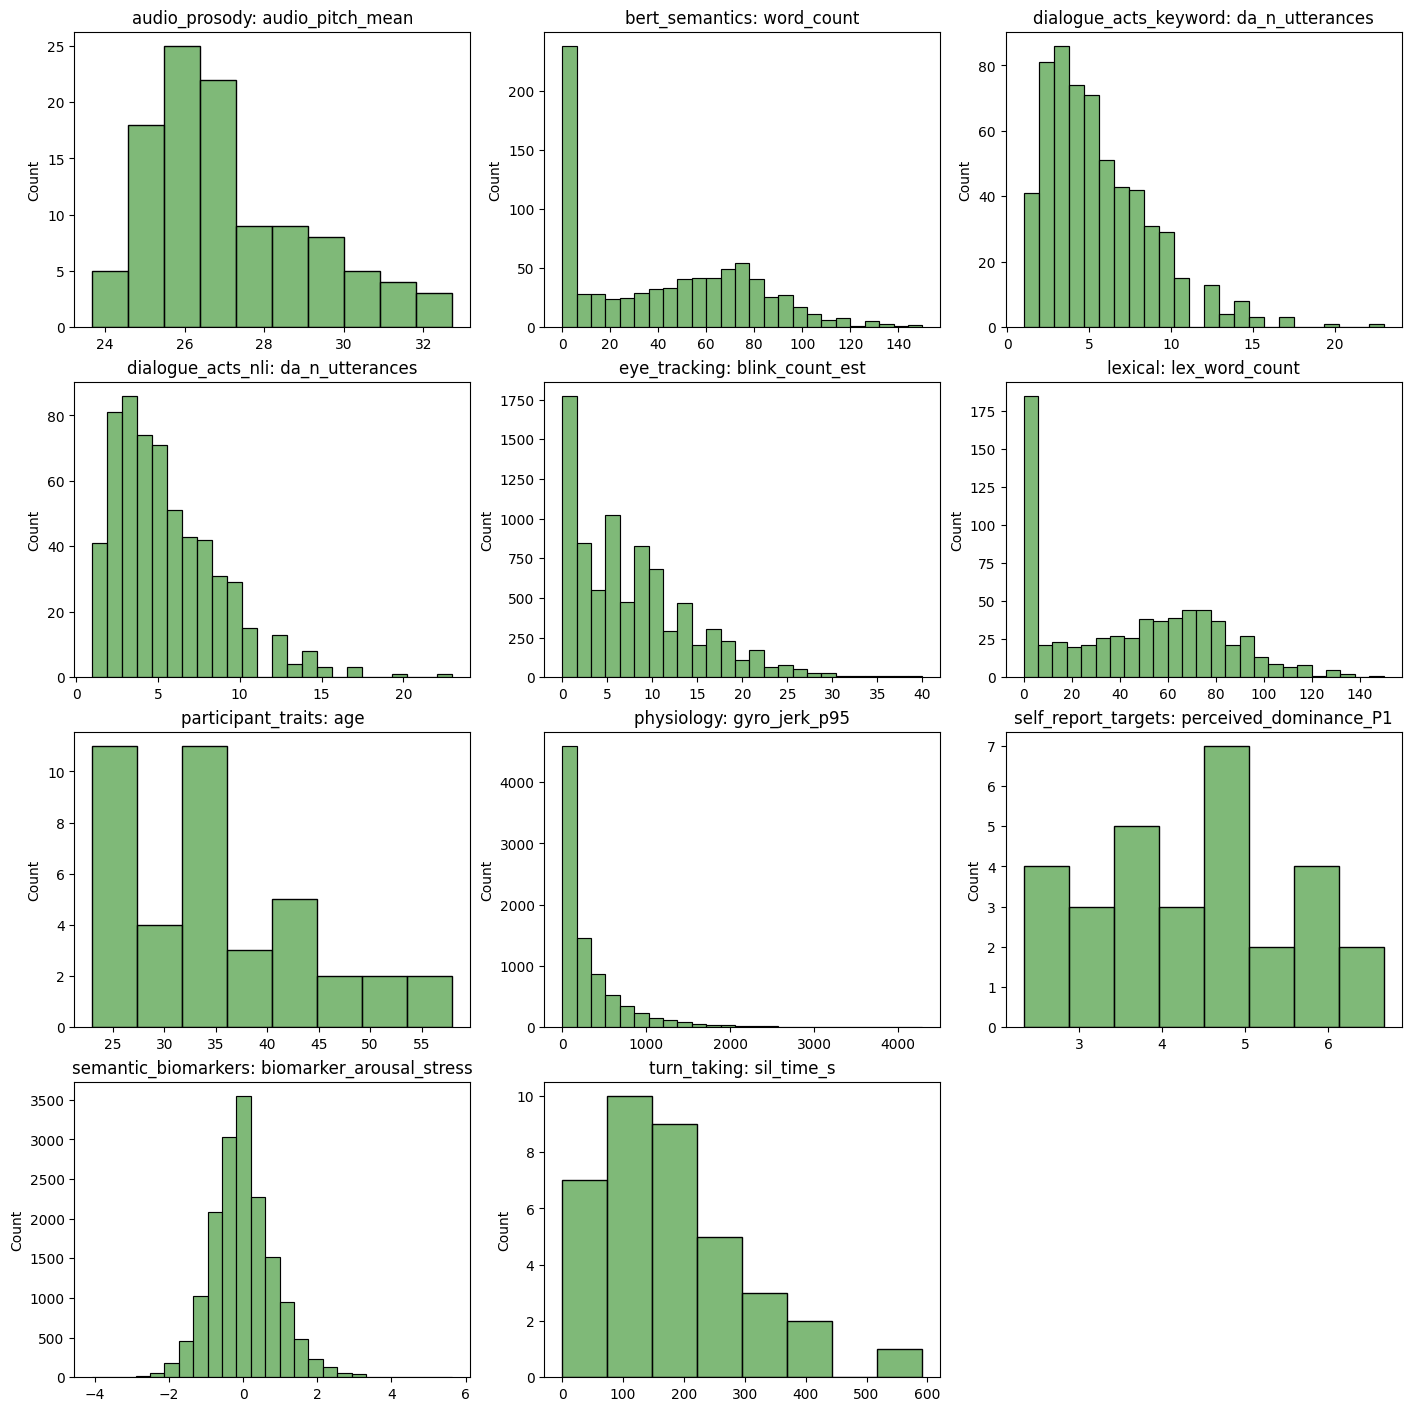

In [3]:
# Plot one coverage-and-skew overview spanning every generated feature family.
plot_inventory = feature_inventory.copy()
plot_inventory["abs_skew"] = plot_inventory["skew"].abs().clip(upper=6)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sns.boxplot(data=plot_inventory, y="family", x="coverage_pct", color="#4C78A8", ax=axes[0])
axes[0].set(xlabel="Observed values (%)", ylabel="", title="Feature coverage by family")
sns.boxplot(data=plot_inventory.dropna(subset=["abs_skew"]), y="family", x="abs_skew", color="#F58518", ax=axes[1])
axes[1].axvline(1, color="#E45756", linestyle="--", linewidth=1)
axes[1].set(xlabel="Absolute skew (clipped at 6)", ylabel="", title="Distribution asymmetry by family")
fig.savefig(OUTPUT_DIR / "feature_coverage_and_skew_by_family.png", dpi=300, bbox_inches="tight")
plt.show()

# Display representative distributions, chosen by highest coverage and variability within each family.
representatives = (
    feature_inventory.query("coverage_pct >= 80 and sd > 0")
    .sort_values(["family", "coverage_pct", "sd"], ascending=[True, False, False])
    .groupby("family", as_index=False)
    .head(1)
)
fig, axes = plt.subplots(4, 3, figsize=(14, 14), constrained_layout=True)
for axis, row in zip(axes.flat, representatives.itertuples()):
    values = frames[row.family][row.feature].dropna()
    sns.histplot(values, bins=min(25, max(8, int(np.sqrt(len(values))))), ax=axis, color="#54A24B")
    axis.set(title=f"{row.family}: {row.feature}", xlabel="")
for axis in axes.flat[len(representatives):]:
    axis.remove()
fig.savefig(OUTPUT_DIR / "representative_feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

## Window-Level Structure for HMM Selection

The HMM uses time windows. The diagnostics below quantify whether each window-level feature varies mainly by task or by group, then identify highly redundant pairs within each feature family. These are descriptive filters, not a substitute for theoretical feature selection.

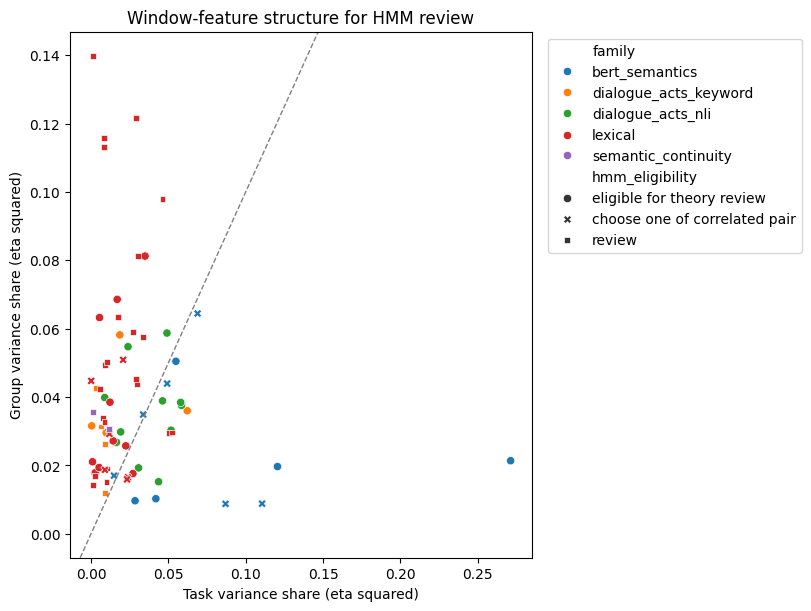

,family,hmm_eligibility,size
0,bert_semantics,choose one of correlated pair,6
1,bert_semantics,eligible for theory review,5
2,dialogue_acts_keyword,eligible for theory review,6
3,dialogue_acts_keyword,review,5
4,dialogue_acts_nli,eligible for theory review,12
5,eye_tracking,eligible for theory review,23
6,lexical,choose one of correlated pair,6
7,lexical,eligible for theory review,10
8,lexical,review,22
9,physiology,eligible for theory review,100


,family,feature_a,feature_b,spearman_rho
0,lexical,lex_agreement_count,n_spk_rows,0.803890
1,lexical,lex_hedging_count,lex_unique_words,0.857878
2,lexical,lex_hedging_count,lex_word_count,0.863153
3,lexical,lex_unique_words,lex_word_count,0.986782
4,lexical,n_speakers,n_spk_rows,0.887923
5,bert_semantics,bert_umap10,bert_umap8,-0.961840
6,bert_semantics,bert_umap4,bert_umap5,-0.838883
7,bert_semantics,bert_umap4,bert_umap6,0.872107
8,bert_semantics,bert_umap5,bert_umap6,-0.962540
9,bert_semantics,bert_umap5,bert_umap7,-0.842816


In [4]:
def eta_squared_by_category(values: pd.Series, categories: pd.Series) -> float:
    """Return descriptive variance share explained by one categorical grouping."""
    valid = pd.DataFrame({"value": values, "category": categories}).dropna()
    if len(valid) < 3 or valid["value"].nunique() < 2 or valid["category"].nunique() < 2:
        return np.nan
    grand_mean = valid["value"].mean()
    total_ss = ((valid["value"] - grand_mean) ** 2).sum()
    between_ss = sum(
        len(group) * (group["value"].mean() - grand_mean) ** 2
        for _, group in valid.groupby("category", observed=True)
    )
    return between_ss / total_ss if total_ss else np.nan

window_structure: list[dict[str, object]] = []
redundant_pairs: list[dict[str, object]] = []
for family, frame in frames.items():
    if SOURCES[family][1] != "window" or not {"group_id", "task_id"}.issubset(frame.columns):
        continue
    candidates = [column for column in frame if is_candidate_column(column, frame[column])]
    for column in candidates:
        window_structure.append({
            "family": family,
            "feature": column,
            "eta_sq_task": eta_squared_by_category(frame[column], frame["task_id"]),
            "eta_sq_group": eta_squared_by_category(frame[column], frame["group_id"]),
        })
    eligible = feature_inventory.query("family == @family and coverage_pct >= 80 and sd > 0")["feature"]
    eligible = [column for column in eligible if column in candidates]
    if len(eligible) >= 2:
        correlations = frame[eligible].corr(method="spearman", min_periods=20)
        for left_index, left in enumerate(eligible):
            for right in eligible[left_index + 1:]:
                rho = correlations.loc[left, right]
                if pd.notna(rho) and abs(rho) >= 0.80:
                    redundant_pairs.append({"family": family, "feature_a": left, "feature_b": right, "spearman_rho": rho})

window_structure = pd.DataFrame(window_structure)
redundant_pairs = pd.DataFrame(redundant_pairs)
hmm_candidates = feature_inventory.merge(window_structure, on=["family", "feature"], how="left")
hmm_candidates = hmm_candidates.query("granularity == 'window'").copy()
hmm_candidates["highly_redundant"] = hmm_candidates["feature"].isin(
    redundant_pairs["feature_a"].tolist() + redundant_pairs["feature_b"].tolist()
)
hmm_candidates["hmm_eligibility"] = np.select(
    [hmm_candidates["near_constant"], hmm_candidates["low_coverage"], hmm_candidates["sparse_count"], hmm_candidates["highly_redundant"]],
    ["exclude", "review", "review", "choose one of correlated pair"],
    default="eligible for theory review",
)
hmm_candidates.to_csv(OUTPUT_DIR / "hmm_candidate_diagnostics.tsv", sep="\t", index=False)
redundant_pairs.to_csv(OUTPUT_DIR / "window_feature_redundancy_pairs.tsv", sep="\t", index=False)

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
plot_candidates = hmm_candidates.dropna(subset=["eta_sq_task", "eta_sq_group"])
sns.scatterplot(
    data=plot_candidates, x="eta_sq_task", y="eta_sq_group", hue="family", style="hmm_eligibility", ax=ax
)
ax.axline((0, 0), slope=1, linestyle="--", color="0.5", linewidth=1)
ax.set(xlabel="Task variance share (eta squared)", ylabel="Group variance share (eta squared)", title="Window-feature structure for HMM review")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.savefig(OUTPUT_DIR / "hmm_task_vs_group_structure.png", dpi=300, bbox_inches="tight")
plt.show()

display(hmm_candidates.groupby(["family", "hmm_eligibility"], as_index=False).size())
display(redundant_pairs.head(20))

## Task-Level Structure for Prediction Selection

Prediction operates on a very small group-task sample. Candidate features are therefore summarized at group-task level, screened for usable coverage and variance, and kept separate from the self-report target table.

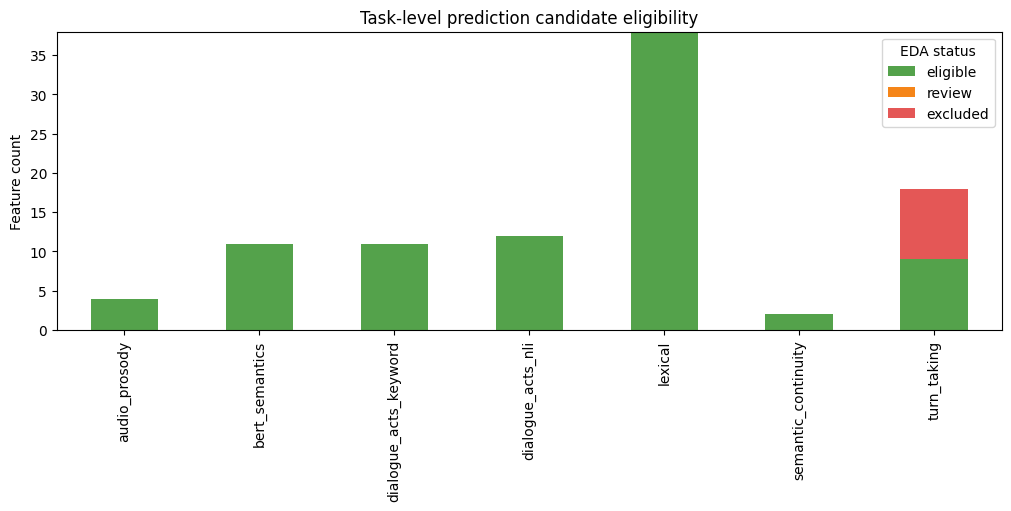

,family,n_features,eligible,review,excluded
0,audio_prosody,4,4,0,0
1,bert_semantics,11,11,0,0
2,dialogue_acts_keyword,11,11,0,0
3,dialogue_acts_nli,12,12,0,0
4,lexical,38,38,0,0
5,semantic_continuity,2,2,0,0
6,turn_taking,18,9,0,9


,feature,coverage_pct,mean,sd,skew,recommended_handling
369,cooperative_mean,33.333333,3.700000,0.621378,-0.746773,review: low coverage
357,engagement_mean,100.000000,5.402800,0.716212,-0.543759,eligible for theory review
360,equality_of_contribution_mean,33.333333,5.050000,0.831665,-0.535107,review: low coverage
374,fairness_mean,33.333333,6.200000,0.387298,0.188270,review: low coverage
361,info_sharing_mean,33.333333,5.400000,0.668747,0.101005,review: low coverage
362,mental_demand_mean,100.000000,3.822233,0.956608,0.071347,eligible for theory review
363,perceived_control_mean,66.666667,4.895800,0.704950,-0.453967,review: low coverage
364,perceived_dominance_P1,100.000000,4.350167,1.181290,0.187844,eligible for theory review
365,perceived_dominance_P2,100.000000,4.666700,0.689283,-0.400704,eligible for theory review
366,perceived_dominance_P3,100.000000,4.844467,0.949811,-0.363571,eligible for theory review


In [5]:
def to_group_task(frame: pd.DataFrame) -> pd.DataFrame | None:
    """Aggregate a generated family to one anonymized group-task row when task keys exist."""
    task_column = next((column for column in ("task_id", "task") if column in frame), None)
    if "group_id" not in frame or task_column is None:
        return None
    features = [column for column in frame if is_candidate_column(column, frame[column])]
    if not features:
        return None
    aggregated = frame.groupby(["group_id", task_column], as_index=False)[features].mean(numeric_only=True)
    return aggregated.rename(columns={task_column: "task_id"})

prediction_summaries: list[pd.DataFrame] = []
for family, frame in frames.items():
    if family in {"self_report_targets", "participant_traits"}:
        continue
    group_task = to_group_task(frame)
    if group_task is None:
        continue
    summary = feature_summary(family, "group_task", group_task)
    prediction_summaries.append(summary)

prediction_candidates = pd.concat(prediction_summaries, ignore_index=True)
prediction_candidates["low_coverage"] = prediction_candidates["coverage_pct"] < 80
prediction_candidates["near_constant"] = (prediction_candidates["n_unique"] <= 2) | (prediction_candidates["sd"] == 0)
prediction_candidates["sparse_count"] = prediction_candidates["zero_pct"] >= 80
prediction_candidates["prediction_eligibility"] = np.select(
    [prediction_candidates["near_constant"], prediction_candidates["low_coverage"], prediction_candidates["sparse_count"]],
    ["exclude", "review", "review"], default="eligible for theory review"
)
prediction_candidates.to_csv(OUTPUT_DIR / "prediction_candidate_diagnostics.tsv", sep="\t", index=False)

# Target and participant-trait EDA remain descriptive context, never predictor ranking inputs here.
target_summary = feature_inventory.query("family == 'self_report_targets'").copy()
trait_summary = feature_inventory.query("family == 'participant_traits'").copy()
target_summary.to_csv(OUTPUT_DIR / "target_distribution_diagnostics.tsv", sep="\t", index=False)
trait_summary.to_csv(OUTPUT_DIR / "trait_distribution_diagnostics.tsv", sep="\t", index=False)

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
plot_prediction = prediction_candidates.groupby("family", as_index=False).agg(
    n_features=("feature", "size"), eligible=("prediction_eligibility", lambda values: int((values == "eligible for theory review").sum())),
    review=("prediction_eligibility", lambda values: int((values == "review").sum())),
    excluded=("prediction_eligibility", lambda values: int((values == "exclude").sum())),
)
plot_prediction.set_index("family")[["eligible", "review", "excluded"]].plot(
    kind="bar", stacked=True, color=["#54A24B", "#F58518", "#E45756"], ax=ax
)
ax.set(xlabel="", ylabel="Feature count", title="Task-level prediction candidate eligibility")
ax.legend(title="EDA status")
fig.savefig(OUTPUT_DIR / "prediction_candidate_eligibility.png", dpi=300, bbox_inches="tight")
plt.show()

display(plot_prediction)
display(target_summary[["feature", "coverage_pct", "mean", "sd", "skew", "recommended_handling"]])